<a href="https://colab.research.google.com/github/SangResidata/exam-data-professional-certifications-credential-portofolio/blob/main/ESAS-CSDA/CSDA_ujian_Wisang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table width="100%" style="border: none;">
  <tr style="border: none;">
    <td style="text-align: center; border: none;">
      <h1 style="margin: 0;">TECHSHOP</h1>
      <h3 style="color: gray;">Performa Penjualan selama 2025 dan prediksinya</h3>
      <hr width="50%">
      <p><b>Oleh: Wisang Residata, M.T.</b></p>
    </td>
  </tr>
</table>

In [1]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.3 MB/s eta 0:00:00


## 1. Impor Library yang diperlukan

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from faker import Faker
import random
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 2. Mempersiapkan Data Penjualan

In [3]:
# Inisialisasi Faker
fake = Faker('id_ID')
random.seed(42)
np.random.seed(42)

# List bulan dari Januari hingga Desember 2025
bulan_list = [
    "Januari", "Februari", "Maret", "April", "Mei", "Juni",
    "Juli", "Agustus", "September", "Oktober", "November", "Desember"
]

data = []

slope = 2.5
intercept = 100_000_000

for i, bulan in enumerate(bulan_list):
    # Laptop: Kita buat tren yang sedikit naik tiap bulan agar terlihat natural
    # Base 150jt + (incremental per bulan) + noise
    laptop = 150_000_000 + (i * 15_000_000) + random.randint(-20_000_000, 20_000_000)

    # Smartphone: Dibuat BERDASARKAN angka Laptop (Linear Relationship)
    # Kita tambahkan sedikit noise agar tidak menjadi garis lurus sempurna
    noise = np.random.normal(0, 30_000_000)
    smartphone = (slope * laptop) + intercept + noise

    # Tablet: Tetap acak/random sesuai permintaan sebelumnya
    tablet = random.randint(50_000_000, 200_000_000)

    data.append({
        "Bulan": bulan,
        "Laptop": laptop,
        "Smartphone": smartphone,
        "Tablet": tablet
    })

# 3. Membuat DataFrame
df_sales = pd.DataFrame(data)


# Menampilkan dataset
print(df_sales)

        Bulan     Laptop    Smartphone     Tablet
0     Januari  137471301  4.585797e+08   56713773
1    Februari  163456905  5.044943e+08  115737657
2       Maret  174979419  5.568792e+08   87456926
3       April  181878334  6.003867e+08  196395715
4         Mei  195834366  5.825613e+08  163258777
5        Juni  207132899  6.108081e+08   57998630
6        Juli  226287781  7.130958e+08  108690184
7     Agustus  250613608  7.495571e+08  185655277
8   September  251780798  7.153678e+08  103375074
9     Oktober  301570403  8.702028e+08  162613994
10   November  294793519  8.230813e+08  170583634
11   Desember  334544950  9.223905e+08  124676249


#3.Analisa Performa Penjualan

In [4]:
df_sales

,Bulan,Laptop,Smartphone,Tablet
0,Januari,137471301,4.585797e+08,56713773
1,Februari,163456905,5.044943e+08,115737657
2,Maret,174979419,5.568792e+08,87456926
3,April,181878334,6.003867e+08,196395715
4,Mei,195834366,5.825613e+08,163258777
5,Juni,207132899,6.108081e+08,57998630
6,Juli,226287781,7.130958e+08,108690184
7,Agustus,250613608,7.495571e+08,185655277
8,September,251780798,7.153678e+08,103375074
9,Oktober,301570403,8.702028e+08,162613994


In [5]:
df_sales.describe()

,Laptop,Smartphone,Tablet
count,1.200000e+01,1.200000e+01,1.200000e+01
mean,2.266954e+08,6.756171e+08,1.277630e+08
std,6.109227e+07,1.470820e+08,4.769451e+07
min,1.374713e+08,4.585797e+08,5.671377e+07
25%,1.801536e+08,5.761408e+08,9.939554e+07
50%,2.167103e+08,6.619520e+08,1.202070e+08
75%,2.625340e+08,7.679381e+08,1.650900e+08
max,3.345450e+08,9.223905e+08,1.963957e+08


In [6]:
total_omset = df_sales[['Laptop', 'Smartphone', 'Tablet']].sum()
total_omset

,0
Laptop,2.720344e+09
Smartphone,8.107405e+09
Tablet,1.533156e+09


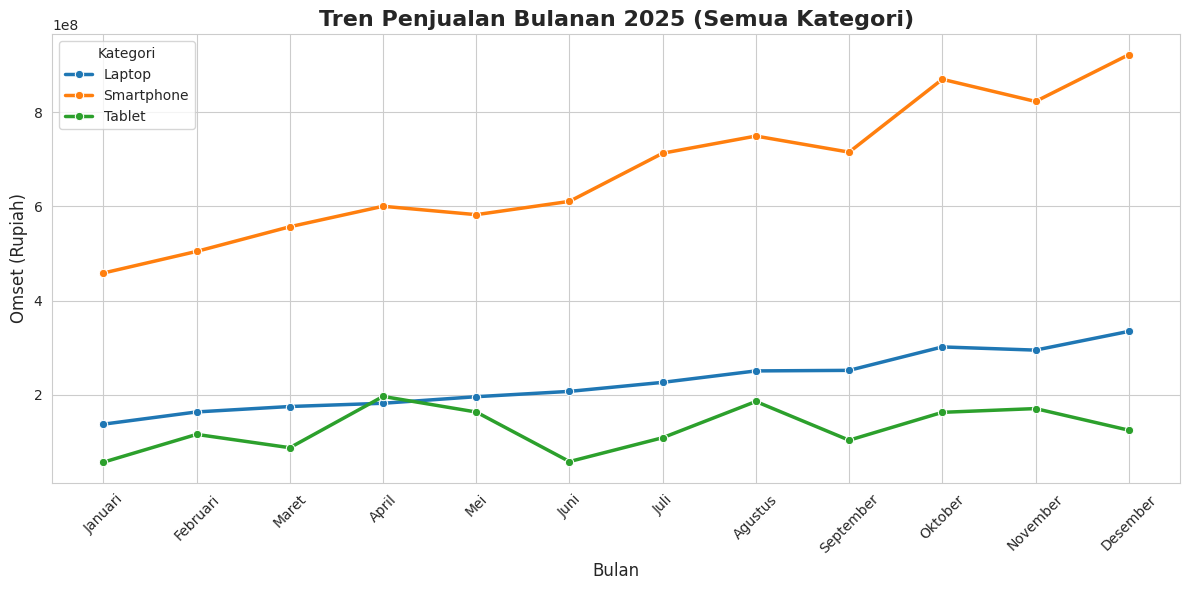

In [7]:
#membuat grafik penjualan
# mengubah struktur df_sales ke dalam format 'melting'
df_melted = df_sales.melt(id_vars='Bulan', var_name='Kategori', value_name='Omset')

# Mengurutkan bulan agar sesuai kalender (bukan alfabet)
df_melted['Bulan'] = pd.Categorical(df_melted['Bulan'], categories=bulan_list, ordered=True)

# Membuat Plot
plt.figure(figsize=(12, 6))  # Mengatur ukuran kanvas
sns.set_style("whitegrid")  # Menggunakan tema grid putih

# Menampilkan lineplot dengan hue berdasarkan Kategori
ax_sns = sns.lineplot(data=df_melted, x='Bulan', y='Omset', hue='Kategori',
                      marker='o',  # Menambahkan titik pada setiap data
                      linewidth=2.5) # Ketebalan garis

# Mempercantik Judul dan Label
plt.title('Tren Penjualan Bulanan 2025 (Semua Kategori)', fontsize=16, fontweight='bold')
plt.ylabel('Omset (Rupiah)', fontsize=12)
plt.xlabel('Bulan', fontsize=12)
plt.xticks(rotation=45)     # Memutar label bulan agar tidak tumpang tindih

# Menampilkan Grafik Seaborn
plt.tight_layout() # Menyesuaikan layout agar tidak terpotong
plt.show() # Menampilkan window grafik

Dari grafik trend penjualan selama 12 bulan terlitat Bahwa Smartphone selalu mempunyai omset penjualan tertinggi setiap bulannya, sedangkan tabletselalu menjadi baang dengan omset penjualan terendah tiap bulannnya, kecuali pada bulan April.

# 4. Prediksi penjualan untuk 3 bulan kedepan

=== DATASET PENJUALAN LINEAR (FAKER) ===
        Bulan     Laptop  Smartphone     Tablet
0     Januari  137471301 458,579,677   56713773
1    Februari  163456905 504,494,333  115737657
2       Maret  174979419 556,879,204   87456926
3       April  181878334 600,386,731  196395715
4         Mei  195834366 582,561,314  163258777
5        Juni  207132899 610,808,139   57998630
6        Juli  226287781 713,095,837  108690184
7     Agustus  250613608 749,557,062  185655277
8   September  251780798 715,367,763  103375074
9     Oktober  301570403 870,202,809  162613994
10   November  294793519 823,081,267  170583634
11   Desember  334544950 922,390,482  124676249

=== KORELASI ANTAR BARANG ===
           Laptop Smartphone Tablet
Laptop      1.000      0.990  0.385
Smartphone  0.990      1.000  0.431
Tablet      0.385      0.431  1.000


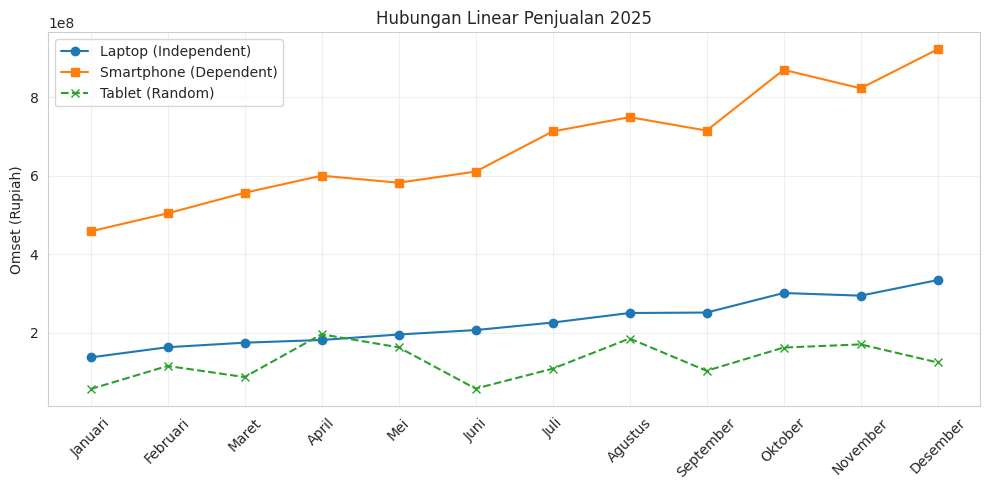

In [8]:
# 4. Analisa Singkat & Cek Korelasi
print("=== DATASET PENJUALAN LINEAR (FAKER) ===")
pd.options.display.float_format = '{:,.0f}'.format
print(df_sales)

print("\n=== KORELASI ANTAR BARANG ===")
# melakukan perhitungan korelasi
korelasi_matrix =df_sales[['Laptop', 'Smartphone', 'Tablet']].corr(method='pearson')
print(korelasi_matrix.to_string(formatters={'Laptop': '{:,.3f}'.format,
                                            'Smartphone': '{:,.3f}'.format,
                                            'Tablet': '{:,.3f}'.format}))

# 5. Visualisasi untuk Verifikasi
plt.figure(figsize=(10, 5))
plt.plot(df_sales['Bulan'], df_sales['Laptop'], label='Laptop (Independent)', marker='o')
plt.plot(df_sales['Bulan'], df_sales['Smartphone'], label='Smartphone (Dependent)', marker='s')
plt.plot(df_sales['Bulan'], df_sales['Tablet'], label='Tablet (Random)', marker='x', linestyle='--')

plt.title('Hubungan Linear Penjualan 2025')
plt.ylabel('Omset (Rupiah)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

dari perhitungan korelasi dan diperjelas dengan grafik, terlihat bahwa ada hubungan korelasi yang sangat kuat antara Penjaulan laptop dan penjualan Smartphone.

In [9]:
#Melakukan Pemodelan Regresi Linear

# --- 1. Memisahkan Fitur (X) dan Target (y) ---
X = df_sales[['Laptop', 'Tablet']]
y = df_sales['Smartphone']

# --- 2. Membagi Dataset (Training & Testing) ---
# test_size=0.2 berarti 20% data digunakan untuk testing (sekitar 2-3 bulan)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}\n")

# --- 3. Membuat dan Melatih Model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- 4. Evaluasi dan Output Hasil ---
y_pred = model.predict(X_test)

print("=== HASIL MULTIPLE LINEAR REGRESSION ===")
print(f"Intercept (Beta 0)     : {model.intercept_:,.2f}")
print(f"Koefisien Laptop (B1) : {model.coef_[0]:.4f}")
print(f"Koefisien Tablet (B2) : {model.coef_[1]:.4f}")
print(f"R-squared Score       : {r2_score(y_test, y_pred):.4f}")

Jumlah data training: 9
Jumlah data testing: 3

=== HASIL MULTIPLE LINEAR REGRESSION ===
Intercept (Beta 0)     : 115,553,742.98
Koefisien Laptop (B1) : 2.3523
Koefisien Tablet (B2) : 0.2122
R-squared Score       : 0.9935


=== TABEL PREDIKSI PENJUALAN (3 BULAN KE DEPAN) ===
           Bulan      Laptop    Smartphone      Tablet
0   Januari 2026 335,081,300   933,359,020 160,037,499
1  Februari 2026 351,756,060   973,011,630 165,002,808
2     Maret 2026 368,430,821 1,012,664,241 169,968,117
--------------------------------------------------


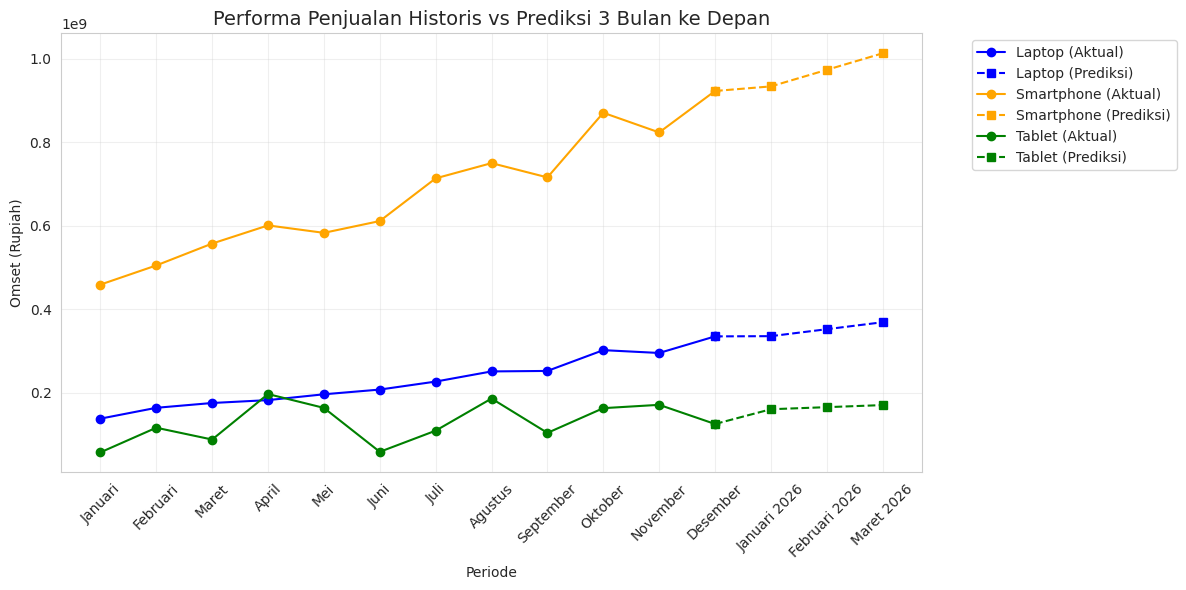

In [10]:
#Prediksi penjualan selama 3 bulan kedepan

# --- 1. Membuat fitur X berupa angka urut 1 sampai 12
X_hist = np.arange(1, len(df_sales) + 1).reshape(-1, 1)

# Menentukan target y untuk masing-masing kategori
y_laptop = df_sales['Laptop'].values
y_smartphone = df_sales['Smartphone'].values
y_tablet = df_sales['Tablet'].values

# --- 2. Pemodelan & Prediksi 3 Bulan ke Depan ---
# Indeks bulan 13 (Jan 2026), 14 (Feb 2026), 15 (Mar 2026)
X_future = np.array([13, 14, 15]).reshape(-1, 1)
bulan_future = ["Januari 2026", "Februari 2026", "Maret 2026"]

predictions = {"Bulan": bulan_future}
categories = ["Laptop", "Smartphone", "Tablet"]

# Loop untuk menghitung regresi tiap kategori
for cat in categories:
    model = LinearRegression()
    # Training menggunakan data historis
    model.fit(X_hist, df_sales[cat])
    # Prediksi masa depan
    predictions[cat] = model.predict(X_future)

# Membuat DataFrame hasil prediksi
df_prediksi = pd.DataFrame(predictions)

# --- 3. Output Tabel Prediksi ---
print("=== TABEL PREDIKSI PENJUALAN (3 BULAN KE DEPAN) ===")
pd.options.display.float_format = '{:,.0f}'.format
print(df_prediksi)
print("-" * 50)

# --- 4. Visualisasi Hasil ---
plt.figure(figsize=(12, 6))

colors = {"Laptop": "blue", "Smartphone": "orange", "Tablet": "green"}

for cat in categories:
    # Plot Data Historis (df_sales)
    plt.plot(df_sales['Bulan'], df_sales[cat], label=f"{cat} (Aktual)",
             color=colors[cat], marker='o')

    # Menghubungkan data terakhir ke data prediksi
    y_last = [df_sales[cat].iloc[-1]] + list(df_prediksi[cat])
    x_future_labels = [df_sales['Bulan'].iloc[-1]] + bulan_future

    # Plot Data Prediksi (Garis Putus-putus)
    plt.plot(x_future_labels, y_last, label=f"{cat} (Prediksi)",
             color=colors[cat], linestyle='--', marker='s')

plt.title("Performa Penjualan Historis vs Prediksi 3 Bulan ke Depan", fontsize=14)
plt.ylabel("Omset (Rupiah)")
plt.xlabel("Periode")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Tampilkan Grafik
plt.show()

KESIMPULAN:
1. Smartphone:
Merupakan kontributor omset tertinggi dan memiliki pertumbuhan paling agresif. Model menangkap tren kenaikan yang kuat. Prediksi menunjukkan omset akan menembus angka di atas Rp 850 Juta pada awal 2026. Ini adalah area dengan potensi profit terbesar.

2. Laptop.
enunjukkan pertumbuhan yang stabil dan konsisten. Tren linear terlihat sangat jelas di sini. Model memprediksi kenaikan gradual menuju kisaran Rp 325 Juta di bulan Maret 2026.

3. Tablet.
Memiliki omset terendah dan fluktuasi yang tidak beraturan selama tahun 2025. Karena data historisnya cenderung stagnan atau sedikit menurun di akhir tahun, model regresi menghasilkan prediktor dengan slope negatif tipis. Prediksi untuk 2026 menunjukkan tren yang menurun di bawah Rp 100 Juta.


In [11]:
df_sales.to_csv('df_sales.csv', index=False)